**Author**: Felipe Matheus <br>
**Start Date**: 27/08/2025 <br>
**Refactor Date** 16/09/2025 <br>
**End Date**: 18/09/2025 <br>
**Related Links**:

- Results so far: https://docs.google.com/spreadsheets/d/1OnIWY_bKxgdGU3trECDTL971WfXFPWgbW-dQzgP6KhI/edit?gid=0#gid=0

- Dataset used: https://drive.google.com/drive/u/0/folders/1VsU-taxtwfmDLUu5Z4JmdgXSoxUoB8FI


**Objective** 

The objective of this notebook is to develop a **prediction** model for **conductivity** after the **Annealing** process of given alloys. Comparing AutoGluon performance with H2o

<!-- There was a selection of 12 tries and variations for the models:

- With without purity (Cu alloys and all alloys)
-> Grain size 3 options: 
    - with grain size initial with grain size final 
    - with grain size initial wihout grain size final
    - without grain size initial without grain size final
- With without deep learning -->

# Setup

In [ ]:
import os
import sys
import h2o
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from h2o.automl import H2OAutoML

module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.processing.Processing import Processing
from src.feature_engineering.FeatureEngineering import FeatureEngineering
from src.visualization.Plots import Plots
from src.visualization.Visualization import Visualization
from src.metrics.Evaluations import Evaluations
from src.feature_engineering.Scaler import ScalerHelpers

from config.Variables import Variables

from src.utils import pick_best_non_ensemble, get_good_key

%load_ext autoreload
%autoreload 2

In [ ]:
varv = Variables()

In [ ]:
proc = Processing()
plot = Plots()
feng = FeatureEngineering()
visu = Visualization()
evla = Evaluations()
scla = ScalerHelpers()

In [ ]:
PATH_DATA_RAW = "../../data/raw" 
FILE_NAME_IACS = "dataset_annealing_iacs.csv"

TARGET_VARIABLE = "iacs_final"

PATH_MODELS = "../../models"
PROCESS = "annealing_iacs"

RULES = {
    "grain_size": "grain_size_ratio > 1",
    "iacs": "> 1",
}

MAX_MODELS = 100

In [ ]:
# dfs_to_train = {}
scalers = {}
dfs_norm = {}
hfs = {}
amls = {}
results = {}

In [ ]:
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 24.0.2+12-54, mixed mode, sharing)
  Starting server from C:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\fmfoa\AppData\Local\Temp\tmpdriss45f
  JVM stdout: C:\Users\fmfoa\AppData\Local\Temp\tmpdriss45f\h2o_fmfoa_started_from_python.out
  JVM stderr: C:\Users\fmfoa\AppData\Local\Temp\tmpdriss45f\h2o_fmfoa_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Europe/Paris
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,29 days
H2O_cluster_name:,H2O_from_python_fmfoa_akzns0
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,7.878 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


# Load files

In [ ]:
df_iacs = pd.read_csv(os.path.join(PATH_DATA_RAW, FILE_NAME_IACS))
df_iacs

,material,purity,grain_size,iacs,temperature,time,grain_size_final,iacs_final
0,Cu,99.98,320,97,473,30,~500,100
1,Cu,99.98,320,97,523,600,~800,100
2,Cu,99.98,320,97,573,120,~900,103
3,Cu,99.98,320,96,473,30,~500,99
4,Cu,99.98,320,95,523,600,~800,98
...,...,...,...,...,...,...,...,...
126,Al–0.5Mg–0.5Si (wt%),~99.7,250,58,623,60,~2000,~67.4
127,Al–0.5Mg–0.5Si (wt%),~99.7,250,58,623,120,~2500,~68.2
128,Al–Mn–Mg alloy,~99.5,250,~35,423,60,~400,~38
129,Al–Mn–Mg alloy,~99.5,250,~35,523,60,~800,~43


# Treat DFs and masks

In [ ]:
df_float = proc.df_to_float(
    df_iacs,
    drop_cols=["DOI"], ignore_columns=["material"],
)

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\src\processing\Processing.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_float = df_float.applymap(
c:\Users\fmfoa\Projects\uncertainty-aware-predictors\src\processing\Processing.py:37: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_float = df_float.applymap(


In [ ]:
df_labeled_unique = feng.label_element(df_float).drop_duplicates()
df_to_mask = \
    feng.add_ratio_mask_column(
        feng.add_ratio_mask_column(df_labeled_unique, "grain_size"),
        "iacs",
    )
df_to_mask

,material,purity,grain_size,iacs,temperature,time,grain_size_final,iacs_final,has_Cu,grain_size_ratio,iacs_ratio
0,Cu,99.98,320.0,97.0,473.0,30.0,500.0,100.0,True,1.5625,1.030928
1,Cu,99.98,320.0,97.0,523.0,600.0,800.0,100.0,True,2.5000,1.030928
2,Cu,99.98,320.0,97.0,573.0,120.0,900.0,103.0,True,2.8125,1.061856
3,Cu,99.98,320.0,96.0,473.0,30.0,500.0,99.0,True,1.5625,1.031250
4,Cu,99.98,320.0,95.0,523.0,600.0,800.0,98.0,True,2.5000,1.031579
...,...,...,...,...,...,...,...,...,...,...,...
126,Al–0.5Mg–0.5Si (wt%),99.70,250.0,58.0,623.0,60.0,2000.0,67.4,False,8.0000,1.162069
127,Al–0.5Mg–0.5Si (wt%),99.70,250.0,58.0,623.0,120.0,2500.0,68.2,False,10.0000,1.175862
128,Al–Mn–Mg alloy,99.50,250.0,35.0,423.0,60.0,400.0,38.0,False,1.6000,1.085714
129,Al–Mn–Mg alloy,99.50,250.0,35.0,523.0,60.0,800.0,43.0,False,3.2000,1.228571


In [ ]:
df_masked = \
    df_to_mask.loc[
        df_to_mask.eval(RULES["grain_size"]) &
        df_to_mask.eval(f'iacs_ratio {RULES["iacs"]}')
    ]
df_masked

,material,purity,grain_size,iacs,temperature,time,grain_size_final,iacs_final,has_Cu,grain_size_ratio,iacs_ratio
0,Cu,99.98,320.0,97.0,473.0,30.0,500.0,100.0,True,1.5625,1.030928
1,Cu,99.98,320.0,97.0,523.0,600.0,800.0,100.0,True,2.5000,1.030928
2,Cu,99.98,320.0,97.0,573.0,120.0,900.0,103.0,True,2.8125,1.061856
3,Cu,99.98,320.0,96.0,473.0,30.0,500.0,99.0,True,1.5625,1.031250
4,Cu,99.98,320.0,95.0,523.0,600.0,800.0,98.0,True,2.5000,1.031579
...,...,...,...,...,...,...,...,...,...,...,...
126,Al–0.5Mg–0.5Si (wt%),99.70,250.0,58.0,623.0,60.0,2000.0,67.4,False,8.0000,1.162069
127,Al–0.5Mg–0.5Si (wt%),99.70,250.0,58.0,623.0,120.0,2500.0,68.2,False,10.0000,1.175862
128,Al–Mn–Mg alloy,99.50,250.0,35.0,423.0,60.0,400.0,38.0,False,1.6000,1.085714
129,Al–Mn–Mg alloy,99.50,250.0,35.0,523.0,60.0,800.0,43.0,False,3.2000,1.228571


# Separating DFs

In [ ]:
columns_to_drop = [
    "material",
    "has_Cu",
    "grain_size_ratio",
    "iacs_ratio",
]
mask_cu = df_masked.has_Cu == True

dfs_to_train = {
    "cual_wgsz_wgsf": df_masked[mask_cu].drop(columns=columns_to_drop),
    # "alll_wgsz_wgsf": df_masked.drop(columns=columns_to_drop + ["purity"]),
    "cual_wgsz_ngsf": df_masked[mask_cu].drop(
        columns=columns_to_drop + ["grain_size_final"]
    ),
    # "alll_wgsz_ngsf": df_masked.drop(
    #     columns=columns_to_drop + ["grain_size_final"]  + ["purity"]
    # ),
    "cual_ngsz_ngsf": df_masked[mask_cu].drop(
        columns=columns_to_drop + ["grain_size", "grain_size_final"]
    ),
    # "alll_ngsz_ngsf": df_masked.drop(
    #     columns=columns_to_drop + ["grain_size", "grain_size_final"] + ["purity"]
    # ),
}

In [ ]:
stop_nb()

In [13]:
# import pickle
# import os

# # Define your path
# save_path = f"{varv.PATH_DATA_PROCESSED}dfs_to_train.pkl"

# # Save dictionary
# with open(save_path, "wb") as f:
#     pickle.dump(dfs_to_train, f)

# print(f"✅ Saved dfs_to_train to: {save_path}")

✅ Saved dfs_to_train to: ../../data/processed/dfs_to_train.pkl


In [ ]:
dfs_to_train

{'cual_wgsz_wgsf':      purity  grain_size  iacs  temperature   time  grain_size_final  \
 0     99.98       320.0  97.0        473.0   30.0             500.0   
 1     99.98       320.0  97.0        523.0  600.0             800.0   
 2     99.98       320.0  97.0        573.0  120.0             900.0   
 3     99.98       320.0  96.0        473.0   30.0             500.0   
 4     99.98       320.0  95.0        523.0  600.0             800.0   
 ..      ...         ...   ...          ...    ...               ...   
 98    99.00       180.0  88.0        573.0   30.0             330.0   
 99    99.00       180.0  88.0        673.0   30.0             450.0   
 100   99.00       190.0  87.0        473.0   30.0             270.0   
 101   99.00       190.0  87.0        573.0   30.0             350.0   
 102   99.00       190.0  87.0        673.0   30.0             480.0   
 
      iacs_final  
 0         100.0  
 1         100.0  
 2         103.0  
 3          99.0  
 4          98.0  
 .

In [ ]:
tags = [
    "alll_ngsz_ngsf_ndpl",
    "alll_wgsz_ngsf_ndpl",
    "alll_ngsz_ngsf_wdpl",
    "alll_wgsz_ngsf_wdpl",
    "cual_ngsz_ngsf_ndpl",
    "cual_wgsz_ngsf_ndpl",
    "cual_ngsz_ngsf_wdpl",
    "cual_wgsz_ngsf_wdpl",

    "alll_wgsz_wgsf_ndpl",
    "alll_wgsz_wgsf_wdpl",
    "cual_wgsz_wgsf_ndpl",
    "cual_wgsz_wgsf_wdpl",
    ]

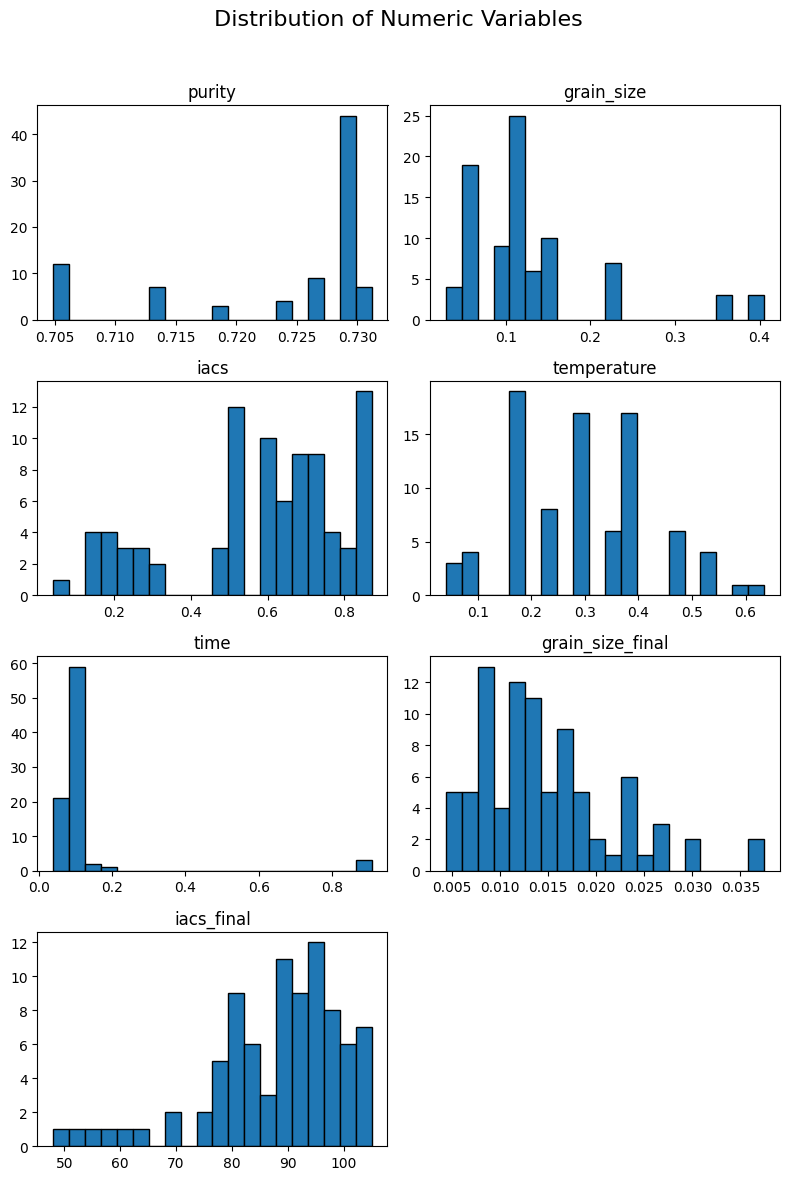

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |█
10:57:14.597: AutoML: XGBoost is not available; skipping it.
10:57:14.661: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 86.0.

██████████████████████████████████████████████████████████████| (done) 100%


c:\Users\fmfoa\Projects\predictors\.predictors-env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
c:\Users\fmfoa\Projects\predictors\.predictors-env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
c:\Users\fmfoa\Projects\predictors\.predictors-env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using

cual_wgsz_wgsf_ndpl {'mape': 0.02631720653493578, 'rmse': 3.5319725702664693, 'mae': 2.0798870596155936} 
 
 --------------------------- 
 

Model saved to: C:\Users\fmfoa\Projects\predictors\models\annealing_iacs\cual_wgsz_wgsf_ndpl\GBM_grid_1_AutoML_11_20250918_105714_model_17
Model saved to: C:\Users\fmfoa\Projects\predictors\models\annealing_iacs\cual_wgsz_wgsf_ndpl\GBM_grid_1_AutoML_11_20250918_105714_model_17
Scaler model saved to: C:\Users\fmfoa\Projects\predictors\models\annealing_iacs\cual_wgsz_wgsf_ndpl\GBM_grid_1_AutoML_11_20250918_105714_model_17


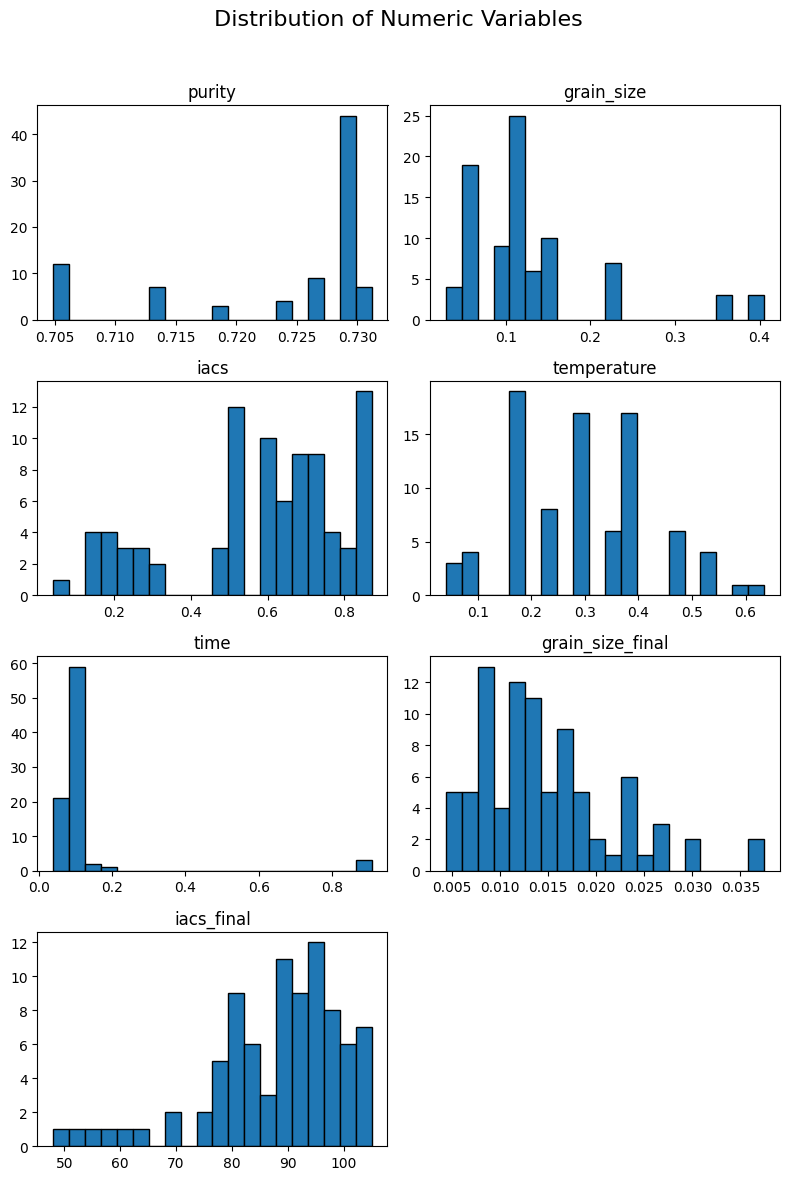

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |█
10:59:19.662: AutoML: XGBoost is not available; skipping it.
10:59:19.707: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 86.0.

██████████████████████████████████████████████████████████████| (done) 100%


c:\Users\fmfoa\Projects\predictors\.predictors-env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
c:\Users\fmfoa\Projects\predictors\.predictors-env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
c:\Users\fmfoa\Projects\predictors\.predictors-env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using

cual_wgsz_wgsf_wdpl {'mape': 0.02631720653493578, 'rmse': 3.5319725702664693, 'mae': 2.0798870596155936} 
 
 --------------------------- 
 

Model saved to: C:\Users\fmfoa\Projects\predictors\models\annealing_iacs\cual_wgsz_wgsf_wdpl\GBM_grid_1_AutoML_12_20250918_105919_model_17
Model saved to: C:\Users\fmfoa\Projects\predictors\models\annealing_iacs\cual_wgsz_wgsf_wdpl\GBM_grid_1_AutoML_12_20250918_105919_model_17
Scaler model saved to: C:\Users\fmfoa\Projects\predictors\models\annealing_iacs\cual_wgsz_wgsf_wdpl\GBM_grid_1_AutoML_12_20250918_105919_model_17


In [13]:
for TAG in tags:
    # Choose DF based on alloys

    df = dfs_to_train[get_good_key(TAG)].copy()

    scalers[TAG] = scla.set_scaler(
        df=df,
        features_range=varv.FEATURES_RANGE_AN.to_dict(),
        target_variable=TARGET_VARIABLE,
    )

    # Small check
    dfs_norm[TAG] = scla.apply_scalers(df, scalers[TAG])
    plot.plot_distributions(dfs_norm[TAG], subplot_dim=(4, 2))

    # Set H2O
    hfs[TAG] = h2o.H2OFrame(dfs_norm[TAG])

    # Chose with or without Deep Learning
    if "wdpl" in TAG:
        amls[TAG] = H2OAutoML(
            max_models=MAX_MODELS,
            keep_cross_validation_predictions=True,
            seed=1,
        )
    else:
        amls[TAG] = H2OAutoML(
            max_models=MAX_MODELS,
            keep_cross_validation_predictions=True,
            seed=1,
            exclude_algos=["DeepLearning"],
        )

    amls[TAG].train(
        x=[col for col in hfs[TAG].columns if col != TARGET_VARIABLE],
        y=TARGET_VARIABLE,
        training_frame=hfs[TAG],
    )

    m = pick_best_non_ensemble(amls[TAG])
    cv_preds = (
        m.cross_validation_holdout_predictions()
        .as_data_frame()
        .to_numpy()
        .flatten()
    )
    y_true = hfs[TAG][TARGET_VARIABLE].as_data_frame().to_numpy().flatten()

    if TARGET_VARIABLE in scalers[TAG]:
        real_y_true2 = scalers[TAG][TARGET_VARIABLE].inverse_transform(y_true)
        real_cv_preds2 = scalers[TAG][TARGET_VARIABLE].inverse_transform(
            cv_preds
        )
    else:
        real_y_true2 = y_true
        real_cv_preds2 = cv_preds

    results[TAG] = {
        "mape": evla.mape(y_true=real_y_true2, y_pred=real_cv_preds2),
        "rmse": evla.rmse(y_true=real_y_true2, y_pred=real_cv_preds2),
        "mae": evla.mae(y_true=real_y_true2, y_pred=real_cv_preds2),
    }
    print(TAG, results[TAG], "\n \n --------------------------- \n \n")
    base_path = os.path.join(PATH_MODELS, PROCESS, TAG)

    models_to_save = [m]
    if amls[TAG].leader not in models_to_save:
        models_to_save.append(amls[TAG].leader)
    for model in models_to_save:
        model_path = h2o.save_model(model=model, path=base_path, force=True)
        print(f"Model saved to: {model_path}")

    with open(os.path.join(base_path, "scalers.pkl"), "wb") as f:
        pickle.dump(scalers[TAG], f)

    print(f"Scaler model saved to: {model_path}")

    with open(os.path.join(base_path, "results.pkl"), "wb") as f:
        pickle.dump(results[TAG], f)

# df_results = pd.DataFrame(results).T
# df_results.to_csv(os.path.join(PATH_MODELS, PROCESS, "final_results.csv"))

# Results

In [ ]:
break
# results = {
#     "alll_ngsz_ngsf_ndpl": {'mape': 0.03361085322771599, 'rmse': 4.097815585659903, 'mae': 2.5445378221148043},
#     "alll_wgsz_ngsf_ndpl": {'mape': 0.035795642054970864, 'rmse': 3.9273057571623853, 'mae': 2.6643193235235785},
#     "alll_ngsz_ngsf_wdpl": {'mape': 0.03361085322771599, 'rmse': 4.097815585659903, 'mae': 2.5445378221148043},
#     "alll_wgsz_ngsf_wdpl": {'mape': 0.028081312941003835, 'rmse': 3.6240382516526024, 'mae': 2.1324297211795717},
#     "cual_ngsz_ngsf_ndpl": {'mape': 0.029210327510185784, 'rmse': 4.024740441958746, 'mae': 2.3258151327311603},
#     "cual_wgsz_ngsf_ndpl": {'mape': 0.026693131358962875, 'rmse': 3.7178968260953633, 'mae': 2.1006942704331064},
#     "cual_ngsz_ngsf_wdpl": {'mape': 0.027912257115054843, 'rmse': 3.32862360594449, 'mae': 2.295998888189584},
#     "cual_wgsz_ngsf_wdpl": {'mape': 0.022956427563834612, 'rmse': 3.5426047647217227, 'mae': 1.8544345108941207},
#     "alll_wgsz_wgsf_ndpl": {'mape': 0.032028519192564775, 'rmse': 3.9660655300007432, 'mae': 2.3431347288252877},
#     "alll_wgsz_wgsf_wdpl": {'mape': 0.03407159553468443, 'rmse': 3.691557782680554, 'mae': 2.507330970301076},
#     "cual_wgsz_wgsf_ndpl": {'mape': 0.02631720653493578, 'rmse': 3.5319725702664693, 'mae': 2.0798870596155936},
#     "cual_wgsz_wgsf_wdpl": {'mape': 0.02631720653493578, 'rmse': 3.5319725702664693, 'mae': 2.0798870596155936},
# }

In [ ]:
pd.DataFrame(results).T

,mape,rmse,mae
alll_ngsz_ngsf_ndpl,0.033611,4.097816,2.544538
alll_wgsz_ngsf_ndpl,0.035796,3.927306,2.664319
alll_ngsz_ngsf_wdpl,0.033611,4.097816,2.544538
alll_wgsz_ngsf_wdpl,0.028081,3.624038,2.132430
cual_ngsz_ngsf_ndpl,0.029210,4.024740,2.325815
cual_wgsz_ngsf_ndpl,0.026693,3.717897,2.100694
cual_ngsz_ngsf_wdpl,0.027912,3.328624,2.295999
cual_wgsz_ngsf_wdpl,0.022956,3.542605,1.854435
alll_wgsz_wgsf_ndpl,0.032029,3.966066,2.343135
alll_wgsz_wgsf_wdpl,0.034072,3.691558,2.507331


In [ ]:
# df_results = pd.DataFrame(results).T
# df_results.to_csv(os.path.join(PATH_MODELS, PROCESS, "final_results.csv"))

# Benchmark — No Scalers: H2O AutoML vs AutoGluon

Tag: `cual_ngsz_ngsf` → features: `purity`, `iacs`, `temperature`, `time`  
**Phase 1 — raw features, no normalisation.**

In [16]:
from sklearn.model_selection import train_test_split
from autogluon.tabular import TabularPredictor

TAG        = "cual_ngsz_ngsf"
SEED       = 1
TEST_SIZE  = 0.2
MAX_MODELS_BENCH = 30       # keep runs fast; raise to 100+ for final
AGL_TIME   = 120            # seconds budget for AutoGluon

df_bench = dfs_to_train[TAG].copy().drop_duplicates().reset_index(drop=True)
print(f"Shape: {df_bench.shape}")
df_bench.head(3)

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Shape: (86, 5)


,purity,iacs,temperature,time,iacs_final
0,99.98,97.0,473.0,30.0,100.0
1,99.98,97.0,523.0,600.0,100.0
2,99.98,97.0,573.0,120.0,103.0


In [17]:
df_train, df_test = train_test_split(
    df_bench, test_size=TEST_SIZE, random_state=SEED
)
df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

y_test = df_test[TARGET_VARIABLE].to_numpy()

print(f"Train: {len(df_train)} rows | Test: {len(df_test)} rows")

Train: 68 rows | Test: 18 rows


## H2O AutoML — no scalers

In [18]:
hf_train = h2o.H2OFrame(df_train)
hf_test  = h2o.H2OFrame(df_test)

aml_h2o = H2OAutoML(
    max_models=MAX_MODELS_BENCH,
    keep_cross_validation_predictions=True,
    exclude_algos=["DeepLearning"],
    seed=SEED,
)
aml_h2o.train(
    y=TARGET_VARIABLE,
    training_frame=hf_train,
)

print("Leader:", aml_h2o.leader.model_id)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
11:05:08.556: AutoML: XGBoost is not available; skipping it.


11:05:08.974: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 68.0.

███████████████████████████████████████████████████████████████| (done) 100%
Leader: GBM_grid_1_AutoML_1_20260410_110508_model_2


In [19]:
aml_h2o.leaderboard.head(10)

model_id,rmse,mse,mae,rmsle,mean_residual_deviance
GBM_grid_1_AutoML_1_20260410_110508_model_2,4.97531,24.7537,3.00011,0.0673421,24.7537
GBM_grid_1_AutoML_1_20260410_110508_model_17,4.99966,24.9966,3.31417,0.0658246,24.9966
StackedEnsemble_AllModels_1_AutoML_1_20260410_110508,5.1321,26.3385,3.4405,0.0695175,26.3385
GBM_5_AutoML_1_20260410_110508,5.13327,26.3505,3.15488,0.0662644,26.3505
GBM_grid_1_AutoML_1_20260410_110508_model_12,5.17744,26.8058,3.14622,0.0698626,26.8058
GBM_grid_1_AutoML_1_20260410_110508_model_34,5.19558,26.994,3.55473,0.0685258,26.994
GBM_grid_1_AutoML_1_20260410_110508_model_13,5.27054,27.7786,3.49592,0.0673059,27.7786
GBM_grid_1_AutoML_1_20260410_110508_model_15,5.37096,28.8473,4.26393,0.068567,28.8473
GBM_grid_1_AutoML_1_20260410_110508_model_7,5.6674,32.1194,4.58716,0.0718499,32.1194
GBM_grid_1_AutoML_1_20260410_110508_model_8,5.72037,32.7227,3.93949,0.0752639,32.7227


In [20]:
y_pred_h2o = (
    aml_h2o.leader
    .predict(hf_test)
    .as_data_frame()
    .iloc[:, 0]
    .to_numpy()
)

metrics_h2o = {
    "mape": evla.mape(y_test, y_pred_h2o),
    "rmse": evla.rmse(y_test, y_pred_h2o),
    "mae":  evla.mae(y_test, y_pred_h2o),
}
print("H2O AutoML (no scalers):", metrics_h2o)

gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
H2O AutoML (no scalers): {'mape': 0.027581586922030485, 'rmse': 3.508016623872283, 'mae': 2.2921234567369675}


c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


## AutoGluon — no scalers

In [21]:
AGL_PATH = f"../../models/{PROCESS}/{TAG}_noscaler_agl"

predictor_agl = TabularPredictor(
    label=TARGET_VARIABLE,
    path=AGL_PATH,
    eval_metric="rmse",
).fit(
    df_train,
    time_limit=AGL_TIME,
    presets="best_quality",
    excluded_model_types=["NN_TORCH"],  # keep parity with H2O (no DL)
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       5.24 GB / 31.57 GB (16.6%)
Disk Space Avail:   773.59 GB / 932.08 GB (83.0%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=6, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon 

(_ray_fit pid=18660) [1000]	valid_set's rmse: 7.8744
(_ray_fit pid=18660) [2000]	valid_set's rmse: 7.76438
(_ray_fit pid=18660) [3000]	valid_set's rmse: 7.7528


(_dystack pid=19168) 	-7.9108	 = Validation score   (-root_mean_squared_error)
(_dystack pid=19168) 	1.01s	 = Training   runtime
(_dystack pid=19168) 	0.01s	 = Validation runtime
(_dystack pid=19168) Fitting model: LightGBM_BAG_L1 ... Training model for up to 6.39s of the 13.60s of remaining time.
(_dystack pid=19168) 	Fitting 6 child models (S1F1 - S1F6) | Fitting with ParallelLocalFoldFittingStrategy (6 workers, per: cpus=1, gpus=0, memory=0.49%)


(_ray_fit pid=15356) [2000]	valid_set's rmse: 7.7599 [repeated 6x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)


(_dystack pid=19168) 	-7.9506	 = Validation score   (-root_mean_squared_error)
(_dystack pid=19168) 	1.29s	 = Training   runtime
(_dystack pid=19168) 	0.01s	 = Validation runtime
(_dystack pid=19168) Fitting model: RandomForestMSE_BAG_L1 ... Training model for up to 0.13s of the 7.34s of remaining time.
(_dystack pid=19168) 	Fitting 1 model on all data (use_child_oof=True) | Fitting with cpus=8, gpus=0
(_dystack pid=19168) 	-5.8213	 = Validation score   (-root_mean_squared_error)
(_dystack pid=19168) 	1.06s	 = Training   runtime
(_dystack pid=19168) 	0.04s	 = Validation runtime
(_dystack pid=19168) Fitting model: WeightedEnsemble_L2 ... Training model for up to 21.64s of the 6.08s of remaining time.
(_dystack pid=19168) 	Fitting 1 model on all data | Fitting with cpus=8, gpus=0, mem=0.0/4.9 GB
(_dystack pid=19168) 	Ensemble Weights: {'RandomForestMSE_BAG_L1': 0.857, 'LightGBMXT_BAG_L1': 0.143}
(_dystack pid=19168) 	-5.75	 = Validation score   (-root_mean_squared_error)
(_dystack pid=19

(_ray_fit pid=24716) [1000]	valid_set's rmse: 6.15115 [repeated 13x across cluster]


(_dystack pid=19168) 	-7.332	 = Validation score   (-root_mean_squared_error)
(_dystack pid=19168) 	1.02s	 = Training   runtime
(_dystack pid=19168) 	0.01s	 = Validation runtime
(_dystack pid=19168) Fitting model: LightGBM_BAG_L2 ... Training model for up to 0.31s of the 0.30s of remaining time.
(_dystack pid=19168) 	Fitting 6 child models (S1F1 - S1F6) | Fitting with ParallelLocalFoldFittingStrategy (6 workers, per: cpus=1, gpus=0, memory=0.36%)
(_ray_fit pid=1176) 	Ran out of time, early stopping on iteration 3062. Best iteration is:
(_ray_fit pid=1176) 	[3061]	valid_set's rmse: 7.2626


(_ray_fit pid=1176) [3000]	valid_set's rmse: 7.2646 [repeated 18x across cluster]


(_dystack pid=19168) 	-7.2595	 = Validation score   (-root_mean_squared_error)
(_dystack pid=19168) 	0.73s	 = Training   runtime
(_dystack pid=19168) 	0.01s	 = Validation runtime
(_dystack pid=19168) Fitting model: WeightedEnsemble_L3 ... Training model for up to 21.64s of the -4.30s of remaining time.
(_dystack pid=19168) 	Fitting 1 model on all data | Fitting with cpus=8, gpus=0, mem=0.0/4.0 GB
(_dystack pid=19168) 	Ensemble Weights: {'RandomForestMSE_BAG_L1': 0.789, 'LightGBM_BAG_L2': 0.211}
(_dystack pid=19168) 	-5.6954	 = Validation score   (-root_mean_squared_error)
(_dystack pid=19168) 	0.01s	 = Training   runtime
(_dystack pid=19168) 	0.0s	 = Validation runtime
(_dystack pid=19168) AutoGluon training complete, total runtime = 25.98s ... Best model: WeightedEnsemble_L3 | Estimated inference throughput: 450.8 rows/s (10 batch size)
(_dystack pid=19168) TabularPredictor saved. To load, use: predictor = TabularPredictor.load("c:\Users\fmfoa\Projects\uncertainty-aware-predictors\mod

In [22]:
predictor_agl.leaderboard(df_test, silent=True)

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,ExtraTreesMSE_BAG_L1,-2.633150,-5.230207,root_mean_squared_error,0.089940,0.028240,0.296683,0.089940,0.028240,0.296683,1,True,5
1,CatBoost_r177_BAG_L1,-2.771258,-3.937737,root_mean_squared_error,0.104130,0.009053,11.560514,0.104130,0.009053,11.560514,1,True,9
2,CatBoost_BAG_L1,-2.854805,-4.047222,root_mean_squared_error,0.144055,0.008484,31.883239,0.144055,0.008484,31.883239,1,True,4
3,WeightedEnsemble_L2,-3.074076,-3.853139,root_mean_squared_error,0.507832,0.028252,13.695679,0.022706,0.000000,0.004001,2,True,10
4,RandomForestMSE_BAG_L1,-3.088689,-5.538846,root_mean_squared_error,0.069598,0.032055,0.407176,0.069598,0.032055,0.407176,1,True,3
5,XGBoost_BAG_L1,-4.242639,-4.702168,root_mean_squared_error,0.236858,0.014834,0.880606,0.236858,0.014834,0.880606,1,True,7
6,LightGBMLarge_BAG_L1,-4.398084,-4.908321,root_mean_squared_error,0.144137,0.004365,1.250558,0.144137,0.004365,1.250558,1,True,8
7,LightGBM_BAG_L1,-4.879540,-7.845817,root_mean_squared_error,0.150188,0.010569,1.623864,0.150188,0.010569,1.623864,1,True,2
8,LightGBMXT_BAG_L1,-4.916566,-7.896488,root_mean_squared_error,0.227498,0.008012,1.112099,0.227498,0.008012,1.112099,1,True,1
9,NeuralNetFastAI_BAG_L1,-4.928563,-5.785884,root_mean_squared_error,0.682890,0.057703,7.496655,0.682890,0.057703,7.496655,1,True,6


In [23]:
y_pred_agl = predictor_agl.predict(df_test).to_numpy()

metrics_agl = {
    "mape": evla.mape(y_test, y_pred_agl),
    "rmse": evla.rmse(y_test, y_pred_agl),
    "mae":  evla.mae(y_test, y_pred_agl),
}
print("AutoGluon (no scalers):", metrics_agl)

AutoGluon (no scalers): {'mape': 0.02454212068347323, 'rmse': 3.074076288689451, 'mae': 2.0581395467122396}


## Comparison — no scalers

In [24]:
df_comparison = pd.DataFrame(
    {
        "H2O AutoML": metrics_h2o,
        "AutoGluon":  metrics_agl,
    }
).T.rename(columns={"mape": "MAPE", "rmse": "RMSE", "mae": "MAE"})

df_comparison.style.highlight_min(axis=0, color="lightgreen")

,MAPE,RMSE,MAE
H2O AutoML,0.027582,3.508017,2.292123
AutoGluon,0.024542,3.074076,2.058140


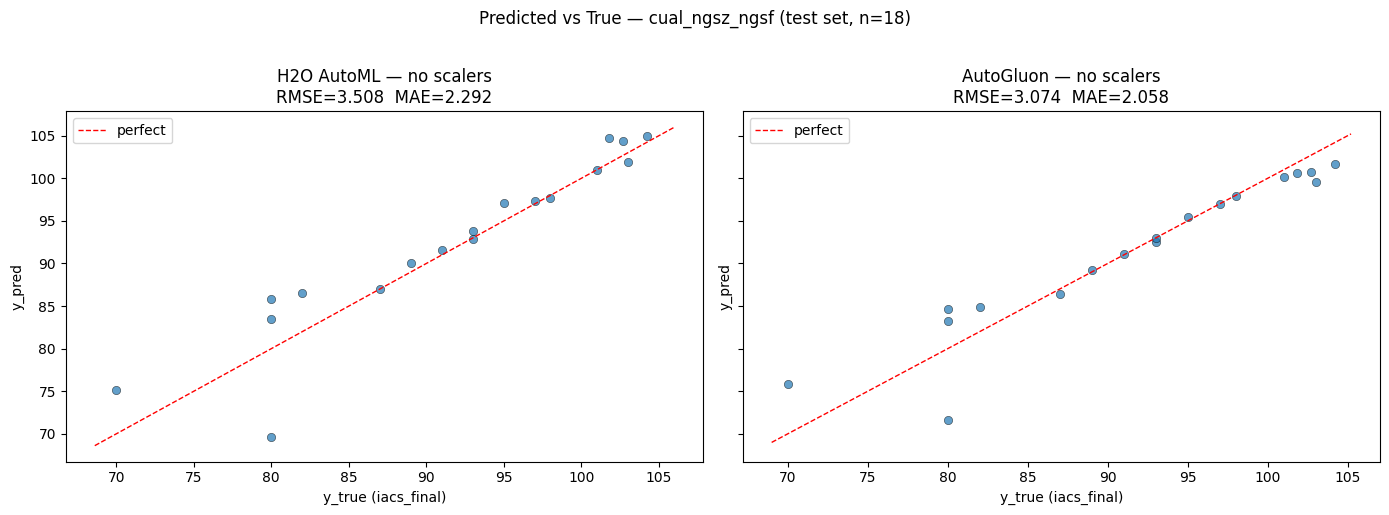

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (label, y_pred) in zip(
    axes,
    [("H2O AutoML", y_pred_h2o), ("AutoGluon", y_pred_agl)],
):
    ax.scatter(y_test, y_pred, alpha=0.7, edgecolors="k", linewidths=0.4)
    lims = [min(y_test.min(), y_pred.min()) - 1,
            max(y_test.max(), y_pred.max()) + 1]
    ax.plot(lims, lims, "r--", linewidth=1, label="perfect")
    ax.set_xlabel("y_true (iacs_final)")
    ax.set_ylabel("y_pred")
    ax.set_title(f"{label} — no scalers\nRMSE={evla.rmse(y_test, y_pred):.3f}  MAE={evla.mae(y_test, y_pred):.3f}")
    ax.legend()

plt.suptitle(f"Predicted vs True — {TAG} (test set, n={len(y_test)})", y=1.02)
plt.tight_layout()
plt.show()